# A production API for your model — the hands-on half

The practical companion to **`api_slides.html`**. By the end of this notebook a real HTTP
server is running on your machine, rejecting bad input with a useful error and answering
predictions in a couple of milliseconds.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 12 | install, sandbox, train a model worth serving |
| 1 · Pydantic | 15–16 | describe the request, watch it reject nonsense |
| 2 · The app | 17–21 | `lifespan` model loading, `/health`, `/predict` |
| 3 · Tests | 22 | `TestClient` — full API tests with no server |
| 4 · A real server | 23–24 | launch uvicorn, hit it over HTTP, measure latency, see `/docs` |
| 5 · Advanced | 25–31 | batch, errors, API keys, middleware, versioning |

**The problem this solves:** a model in a notebook is useful to exactly one person. An API
turns it into something a website, a job, or another team can call.

Everything runs in a throwaway `api_demo/` folder; the last cell stops the server and deletes it.

## Step 0.1 · Install

In [1]:
!pip install -q fastapi 'pydantic>=2' uvicorn scikit-learn pandas requests httpx

In [2]:
import fastapi, pydantic, uvicorn, sklearn
print("fastapi ", fastapi.__version__)
print("pydantic", pydantic.VERSION)
print("uvicorn ", uvicorn.__version__)
print("sklearn ", sklearn.__version__)

fastapi  0.115.2
pydantic 2.11.10
uvicorn  0.31.1
sklearn  1.6.1


/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shamaseen/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Step 0.2 · A sandbox to work in

In [3]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "api_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/03-production-api/api_demo


## Step 0.3 · Train something worth serving

A small churn pipeline — the same shape as session 1, and for the same reason: we persist the
**whole pipeline**, so the API never needs its own copy of the preprocessing code.

In [4]:
import numpy as np, pandas as pd, joblib, os
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(0)
m = 4000
df = pd.DataFrame({
    "tenure_months":  rng.integers(1, 72, m),
    "monthly_charge": rng.normal(65, 20, m).round(2),
    "support_calls":  rng.poisson(1.2, m),
    "plan":           rng.choice(["basic", "plus", "pro"], m, p=[.5, .3, .2]),
})
sc = (-0.04*df.tenure_months + 0.03*df.monthly_charge + 0.55*df.support_calls
      + rng.normal(0, .8, m))
df["churn"] = (sc > sc.mean()).astype(int)

NUM, CAT = ["tenure_months", "monthly_charge", "support_calls"], ["plan"]
pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])),
    ("model", RandomForestClassifier(n_estimators=150, random_state=0))])

Xtr, Xte, ytr, yte = train_test_split(df[NUM+CAT], df.churn, test_size=.25,
                                      random_state=0, stratify=df.churn)
pipe.fit(Xtr, ytr)
auc = roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1])

os.makedirs("app", exist_ok=True)
joblib.dump({"pipeline": pipe, "version": "1.0.0", "features": NUM + CAT,
             "trained_rows": len(Xtr), "test_roc_auc": round(float(auc), 4)},
            "app/model.joblib")
print(f"test ROC AUC {auc:.4f}  ->  saved app/model.joblib")

test ROC AUC 0.8653  ->  saved app/model.joblib


---
# Part 1 — Pydantic: the front door   ·   deck slides 15–16

An API is a **trust boundary**. Everything arriving from outside is a stranger's guess about
what you wanted: strings where you expect numbers, missing fields, `null`, a plan called
`"PRO "` with a trailing space, `tenure_months: -5`.

Pydantic lets you *declare* the shape you accept. FastAPI then rejects anything else before
your code runs, with an error message that tells the caller exactly what was wrong.

In [5]:
%%writefile app/schemas.py
"""Request and response shapes. This file IS the API contract.

typing.Optional / typing.List rather than `str | None` and `list[...]`: PEP 604 unions
need Python 3.10, and an API that only imports on the newest interpreter is a support
problem you do not need.
"""
from typing import List, Literal, Optional

from pydantic import BaseModel, Field, ConfigDict


class Customer(BaseModel):
    """One customer to score. Field(...) carries the validation rules."""
    model_config = ConfigDict(
        extra="forbid",                 # a typo'd field is an error, not a shrug
        json_schema_extra={"examples": [
            {"tenure_months": 12, "monthly_charge": 79.99,
             "support_calls": 3, "plan": "pro"}]})

    tenure_months:  int   = Field(ge=0, le=600,    description="months since signup")
    monthly_charge: float = Field(ge=0, le=10_000, description="current monthly bill")
    support_calls:  int   = Field(ge=0, le=100,    description="calls in the last 90 days")
    plan: Literal["basic", "plus", "pro"]           # anything else is rejected


class Prediction(BaseModel):
    """What we promise to return. Declaring it stops accidental contract changes."""
    churn: bool
    probability: float = Field(ge=0, le=1)
    model_version: str
    request_id: str


class BatchRequest(BaseModel):
    customers: List[Customer] = Field(min_length=1, max_length=1000)


class Health(BaseModel):
    status: Literal["ok", "degraded"]
    model_loaded: bool
    model_version: Optional[str] = None


Writing app/schemas.py


Validation is not theory — try it directly, with no web server involved.

In [6]:
import sys; sys.path.insert(0, ".")
from app.schemas import Customer
from pydantic import ValidationError

good = Customer(tenure_months=12, monthly_charge=79.99, support_calls=3, plan="pro")
print("accepted:", good.model_dump())

for bad, why in [
    ({"tenure_months": -5, "monthly_charge": 50, "support_calls": 1, "plan": "pro"}, "negative tenure"),
    ({"tenure_months": 12, "monthly_charge": 50, "support_calls": 1, "plan": "gold"}, "no such plan"),
    ({"tenure_months": 12, "monthly_charge": 50, "plan": "pro"},                      "missing field"),
    ({"tenure_months": 12, "monthly_charge": 50, "support_calls": 1, "plan": "pro",
      "tenure": 4},                                                                  "unexpected field"),
]:
    try:
        Customer(**bad); print(f"  {why:20} -> ACCEPTED (should not happen)")
    except ValidationError as e:
        err = e.errors()[0]
        print(f"  {why:20} -> rejected: {err['loc']} {err['msg'][:52]}")

accepted: {'tenure_months': 12, 'monthly_charge': 79.99, 'support_calls': 3, 'plan': 'pro'}
  negative tenure      -> rejected: ('tenure_months',) Input should be greater than or equal to 0
  no such plan         -> rejected: ('plan',) Input should be 'basic', 'plus' or 'pro'
  missing field        -> rejected: ('support_calls',) Field required
  unexpected field     -> rejected: ('tenure',) Extra inputs are not permitted


> **Why `extra="forbid"` matters.** Without it, a caller who sends `tenure` instead of
> `tenure_months` gets a *silent default* and a confidently wrong prediction. With it they get
> an error that names the field. Silent acceptance of unknown fields is how bad data gets into
> production one typo at a time.

---
# Part 2 — The application   ·   deck slides 17–21

Three things every model API needs, and one thing most get wrong:

* `GET /health` — for the load balancer and for you at 3am
* `POST /predict` — the actual work
* `/docs` — interactive documentation, free, generated from the schemas
* **load the model once, at startup** — not per request. That is the `lifespan` block below.

In [7]:
%%writefile app/main.py
"""A model API small enough to read in one sitting, shaped like a real one."""
import logging, os, time, uuid
from contextlib import asynccontextmanager

import joblib
import pandas as pd
from fastapi import FastAPI, HTTPException, Request
from fastapi.responses import JSONResponse

from typing import List, Tuple

from app.schemas import BatchRequest, Customer, Health, Prediction

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger("api")

ARTIFACT = os.getenv("MODEL_PATH", "app/model.joblib")
STATE: dict = {}


@asynccontextmanager
async def lifespan(app: FastAPI):
    # startup: load the model ONCE. Loading per request would add ~50ms to every call.
    STATE["bundle"] = joblib.load(ARTIFACT)
    log.info("model %s loaded from %s", STATE["bundle"]["version"], ARTIFACT)
    yield
    STATE.clear()                      # shutdown: let go of it cleanly
    log.info("model unloaded")


app = FastAPI(
    title="Churn API",
    version="1.0.0",
    summary="Scores a customer's probability of churning.",
    lifespan=lifespan,
)


@app.middleware("http")
async def add_timing(request: Request, call_next):
    """Every response carries how long it took. Cheap, and priceless when it gets slow."""
    t0 = time.perf_counter()
    response = await call_next(request)
    response.headers["X-Process-Time-ms"] = f"{(time.perf_counter() - t0) * 1000:.2f}"
    return response


@app.get("/health", response_model=Health, tags=["ops"])
def health():
    """Liveness. Returns degraded rather than 500 so an orchestrator can tell them apart."""
    b = STATE.get("bundle")
    return Health(status="ok" if b else "degraded",
                  model_loaded=b is not None,
                  model_version=b["version"] if b else None)


def _score(rows: List[Customer]) -> List[Tuple[bool, float]]:
    b = STATE.get("bundle")
    if b is None:                                    # never guess when the model is missing
        raise HTTPException(status_code=503, detail="model not loaded")
    frame = pd.DataFrame([r.model_dump() for r in rows])[b["features"]]
    proba = b["pipeline"].predict_proba(frame)[:, 1]
    return [(bool(p >= 0.5), float(round(p, 4))) for p in proba]


@app.post("/predict", response_model=Prediction, tags=["model"])
def predict(customer: Customer):
    churn, proba = _score([customer])[0]
    return Prediction(churn=churn, probability=proba,
                      model_version=STATE["bundle"]["version"],
                      request_id=str(uuid.uuid4())[:8])


@app.post("/predict/batch", response_model=List[Prediction], tags=["model"])
def predict_batch(body: BatchRequest):
    """One model call for the whole batch -- far cheaper than N separate requests."""
    out = _score(body.customers)
    v = STATE["bundle"]["version"]
    return [Prediction(churn=c, probability=p, model_version=v,
                       request_id=str(uuid.uuid4())[:8]) for c, p in out]


@app.exception_handler(Exception)
async def unhandled(request: Request, exc: Exception):
    """Log the detail, return something generic. Stack traces are not for callers."""
    log.exception("unhandled error on %s", request.url.path)
    return JSONResponse(status_code=500, content={"detail": "internal error"})

Writing app/main.py


In [8]:
!ls -la app/
print("\n--- the app is ~90 lines, and that is the whole service ---")

total 13216
drwxrwxr-x 3 shamaseen shamaseen     4096 Aug 24 18:29 .
drwxrwxr-x 3 shamaseen shamaseen     4096 Aug 24 18:29 ..
-rw-rw-r-- 1 shamaseen shamaseen     3287 Aug 24 18:29 main.py
-rw-rw-r-- 1 shamaseen shamaseen 13512511 Aug 24 18:29 model.joblib
drwxrwxr-x 2 shamaseen shamaseen     4096 Aug 24 18:29 __pycache__
-rw-rw-r-- 1 shamaseen shamaseen     1521 Aug 24 18:29 schemas.py

--- the app is ~90 lines, and that is the whole service ---


---
# Part 3 — Test it without a server   ·   deck slide 22

`TestClient` runs the whole application in-process: real routing, real validation, real
responses, no port, no waiting. Fast enough to run on every commit.

In [9]:
from fastapi.testclient import TestClient
from app.main import app

client = TestClient(app)          # entering the context runs the lifespan startup

with client:
    h = client.get("/health")
    print("GET /health ", h.status_code, h.json())

    ok = client.post("/predict", json={"tenure_months": 3, "monthly_charge": 95.0,
                                       "support_calls": 6, "plan": "basic"})
    print("POST /predict", ok.status_code, ok.json())

    bad = client.post("/predict", json={"tenure_months": -1, "monthly_charge": 95.0,
                                        "support_calls": 6, "plan": "gold"})
    print("POST /predict (bad)", bad.status_code)
    for e in bad.json()["detail"]:
        print("   ", e["loc"], "->", e["msg"][:58])

2026-08-24 18:29:27,105 INFO model 1.0.0 loaded from app/model.joblib
2026-08-24 18:29:27,108 INFO HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"
2026-08-24 18:29:27,118 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"
2026-08-24 18:29:27,120 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 422 Unprocessable Entity"
2026-08-24 18:29:27,120 INFO model unloaded


GET /health  200 {'status': 'ok', 'model_loaded': True, 'model_version': '1.0.0'}
POST /predict 200 {'churn': True, 'probability': 1.0, 'model_version': '1.0.0', 'request_id': '8c7f886c'}
POST /predict (bad) 422
    ['body', 'tenure_months'] -> Input should be greater than or equal to 0
    ['body', 'plan'] -> Input should be 'basic', 'plus' or 'pro'


Two things to notice in that output:

* the bad request came back **422**, not 500 — the caller's mistake is reported as the caller's
  mistake, with the offending field named;
* you never wrote that error message. It came from the schema.

In [10]:
# a small test suite -- this is what runs in CI
def test_health_ok():
    with TestClient(app) as c:
        assert c.get("/health").json()["model_loaded"] is True

def test_predict_shape():
    with TestClient(app) as c:
        r = c.post("/predict", json={"tenure_months": 12, "monthly_charge": 60.0,
                                     "support_calls": 1, "plan": "pro"}).json()
        assert set(r) == {"churn", "probability", "model_version", "request_id"}
        assert 0.0 <= r["probability"] <= 1.0

def test_rejects_unknown_plan():
    with TestClient(app) as c:
        assert c.post("/predict", json={"tenure_months": 12, "monthly_charge": 60.0,
                                        "support_calls": 1, "plan": "platinum"}).status_code == 422

def test_batch_returns_one_per_customer():
    with TestClient(app) as c:
        body = {"customers": [{"tenure_months": i, "monthly_charge": 50.0,
                               "support_calls": 0, "plan": "basic"} for i in range(5)]}
        assert len(c.post("/predict/batch", json=body).json()) == 5

for t in [test_health_ok, test_predict_shape, test_rejects_unknown_plan,
          test_batch_returns_one_per_customer]:
    t(); print("PASS", t.__name__)

2026-08-24 18:29:27,154 INFO model 1.0.0 loaded from app/model.joblib
2026-08-24 18:29:27,156 INFO HTTP Request: GET http://testserver/health "HTTP/1.1 200 OK"
2026-08-24 18:29:27,157 INFO model unloaded
2026-08-24 18:29:27,180 INFO model 1.0.0 loaded from app/model.joblib
2026-08-24 18:29:27,189 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 200 OK"
2026-08-24 18:29:27,190 INFO model unloaded
2026-08-24 18:29:27,213 INFO model 1.0.0 loaded from app/model.joblib
2026-08-24 18:29:27,214 INFO HTTP Request: POST http://testserver/predict "HTTP/1.1 422 Unprocessable Entity"
2026-08-24 18:29:27,215 INFO model unloaded


PASS test_health_ok
PASS test_predict_shape
PASS test_rejects_unknown_plan


2026-08-24 18:29:27,238 INFO model 1.0.0 loaded from app/model.joblib
2026-08-24 18:29:27,247 INFO HTTP Request: POST http://testserver/predict/batch "HTTP/1.1 200 OK"
2026-08-24 18:29:27,248 INFO model unloaded


PASS test_batch_returns_one_per_customer


---
# Part 4 — A real server over real HTTP   ·   deck slides 23–24

`TestClient` proves the logic. It does not prove that uvicorn serves it, that the port binds,
or how fast it is. So now start the actual server.

In [11]:
import subprocess, socket, sys, time, urllib.request

def free_port(start=8000):
    for p in range(start, start + 50):
        with socket.socket() as s:
            if s.connect_ex(("127.0.0.1", p)) != 0:
                return p
    raise RuntimeError("no free port")

PORT = free_port()
URL = f"http://127.0.0.1:{PORT}"

SERVER = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "app.main:app", "--host", "127.0.0.1",
     "--port", str(PORT), "--log-level", "warning"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    start_new_session=True)          # detached, so this notebook can always exit cleanly

for _ in range(60):
    try:
        urllib.request.urlopen(f"{URL}/health", timeout=1); break
    except Exception:
        time.sleep(0.5)

print(f"uvicorn serving at {URL}")

uvicorn serving at http://127.0.0.1:8002


In [12]:
import requests, json

print("GET /health")
print(json.dumps(requests.get(f"{URL}/health").json(), indent=2))

r = requests.post(f"{URL}/predict", json={"tenure_months": 2, "monthly_charge": 110.0,
                                          "support_calls": 8, "plan": "basic"})
print(f"\nPOST /predict -> {r.status_code}")
print(json.dumps(r.json(), indent=2))
print("timing header:", r.headers.get("X-Process-Time-ms"), "ms")

GET /health
{
  "status": "ok",
  "model_loaded": true,
  "model_version": "1.0.0"
}

POST /predict -> 200
{
  "churn": true,
  "probability": 1.0,
  "model_version": "1.0.0",
  "request_id": "cc65f870"
}
timing header: 9.35 ms


In [13]:
# what a caller sees when they get it wrong, over the wire
r = requests.post(f"{URL}/predict", json={"tenure_months": "twelve", "monthly_charge": 60,
                                          "support_calls": 1, "plan": "pro"})
print("status:", r.status_code)
print(json.dumps(r.json(), indent=2)[:420])

status: 422
{
  "detail": [
    {
      "type": "int_parsing",
      "loc": [
        "body",
        "tenure_months"
      ],
      "msg": "Input should be a valid integer, unable to parse string as an integer",
      "input": "twelve"
    }
  ]
}


## Step 4.1 · How fast is it?

Measure, do not guess. Single process, one request at a time.

In [14]:
import statistics, time

payload = {"tenure_months": 12, "monthly_charge": 60.0, "support_calls": 1, "plan": "pro"}
requests.post(f"{URL}/predict", json=payload)                     # warm up

single = []
for _ in range(60):
    t0 = time.perf_counter(); requests.post(f"{URL}/predict", json=payload)
    single.append((time.perf_counter() - t0) * 1000)

batch_body = {"customers": [payload] * 100}
t0 = time.perf_counter(); requests.post(f"{URL}/predict/batch", json=batch_body)
batch_ms = (time.perf_counter() - t0) * 1000

single.sort()
p50, p95 = single[len(single)//2], single[int(len(single)*.95)]
print(f"POST /predict         p50 {p50:6.2f} ms   p95 {p95:6.2f} ms")
print(f"POST /predict/batch   100 customers in {batch_ms:.2f} ms "
      f"({batch_ms/100:.3f} ms each)")
print(f"\nbatching is {p50/(batch_ms/100):.0f}x cheaper per customer -- one model call, not 100")

POST /predict         p50   8.32 ms   p95  10.01 ms
POST /predict/batch   100 customers in 9.62 ms (0.096 ms each)

batching is 87x cheaper per customer -- one model call, not 100


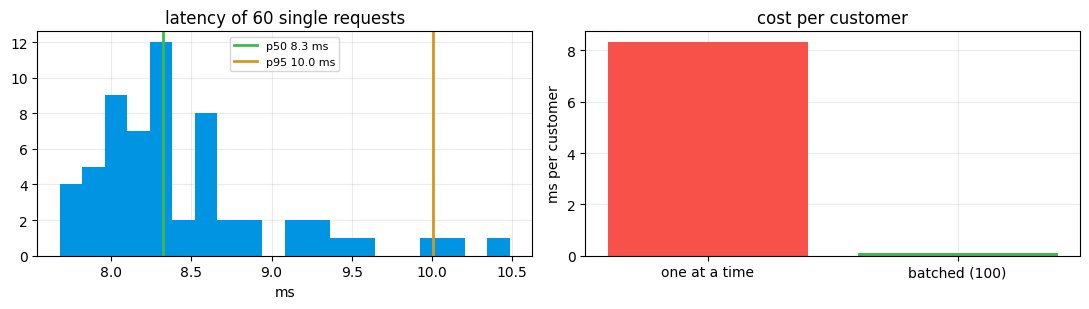

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(single, bins=20, color="#0194e2")
ax[0].axvline(p50, color="#3fb950", lw=2, label=f"p50 {p50:.1f} ms")
ax[0].axvline(p95, color="#d29922", lw=2, label=f"p95 {p95:.1f} ms")
ax[0].set_title("latency of 60 single requests"); ax[0].set_xlabel("ms"); ax[0].legend(fontsize=8)
ax[1].bar(["one at a time", "batched (100)"], [p50, batch_ms/100], color=["#f85149", "#3fb950"])
ax[1].set_ylabel("ms per customer"); ax[1].set_title("cost per customer")
for a in ax: a.grid(alpha=.25); a.set_axisbelow(True)
fig.tight_layout(); plt.show()

## Step 4.2 · `/docs` — the documentation you did not write

FastAPI turns the Pydantic schemas into an OpenAPI specification, and serves an interactive
page from it. Every field, type, bound and example you declared shows up, and callers can try
the endpoint from the browser.

In [16]:
import json, requests
spec = requests.get(f"{URL}/openapi.json").json()
print("paths:", list(spec["paths"]))
print("\nthe /predict request schema, generated from Customer:")
print(json.dumps(spec["components"]["schemas"]["Customer"]["properties"], indent=2)[:500])
print(f"\nInteractive docs:  {URL}/docs")
print(f"Alternative docs:  {URL}/redoc")

paths: ['/health', '/predict', '/predict/batch']

the /predict request schema, generated from Customer:
{
  "tenure_months": {
    "type": "integer",
    "maximum": 600.0,
    "minimum": 0.0,
    "title": "Tenure Months",
    "description": "months since signup"
  },
  "monthly_charge": {
    "type": "number",
    "maximum": 10000.0,
    "minimum": 0.0,
    "title": "Monthly Charge",
    "description": "current monthly bill"
  },
  "support_calls": {
    "type": "integer",
    "maximum": 100.0,
    "minimum": 0.0,
    "title": "Support Calls",
    "description": "calls in the last 90 days"
  },
  

Interactive docs:  http://127.0.0.1:8002/docs
Alternative docs:  http://127.0.0.1:8002/redoc


---
# Part 5 — Advanced   ·   deck slides 25–31

## Step 5.1 · An API key, done simply

Anything reachable needs *some* answer to "who is calling?". A shared key in a header is the
minimum, and `Depends` makes it one line per route.

In [17]:
%%writefile app/secure.py
"""A minimal auth dependency. Real systems use OAuth2/JWT -- the shape is identical."""
import os, secrets
from fastapi import Depends, Header, HTTPException

API_KEY = os.getenv("API_KEY", "dev-key-change-me")


def require_key(x_api_key: str = Header(default="")):
    # compare_digest, not ==, so the comparison time does not leak the key
    if not secrets.compare_digest(x_api_key, API_KEY):
        raise HTTPException(status_code=401, detail="invalid or missing X-API-Key")
    return True

# usage:  @app.post("/predict", dependencies=[Depends(require_key)])

Writing app/secure.py


In [18]:
from fastapi import Depends, FastAPI
from app.secure import require_key
from app.schemas import Customer

demo = FastAPI()

@demo.post("/secure-predict", dependencies=[Depends(require_key)])
def secure_predict(c: Customer):
    return {"ok": True}

with TestClient(demo) as c:
    body = {"tenure_months": 1, "monthly_charge": 10.0, "support_calls": 0, "plan": "basic"}
    print("no key      ->", c.post("/secure-predict", json=body).status_code, "(401 expected)")
    print("wrong key   ->", c.post("/secure-predict", json=body,
                                   headers={"X-API-Key": "nope"}).status_code)
    print("correct key ->", c.post("/secure-predict", json=body,
                                   headers={"X-API-Key": "dev-key-change-me"}).status_code)

2026-08-24 18:29:29,275 INFO HTTP Request: POST http://testserver/secure-predict "HTTP/1.1 401 Unauthorized"
2026-08-24 18:29:29,277 INFO HTTP Request: POST http://testserver/secure-predict "HTTP/1.1 401 Unauthorized"
2026-08-24 18:29:29,278 INFO HTTP Request: POST http://testserver/secure-predict "HTTP/1.1 200 OK"


no key      -> 401 (401 expected)
wrong key   -> 401
correct key -> 200


## Step 5.2 · The rest of the toolkit

```python
# --- CORS, if a browser will call you directly -------------------------------
from fastapi.middleware.cors import CORSMiddleware
app.add_middleware(CORSMiddleware, allow_origins=["https://app.acme.com"],
                   allow_methods=["POST"], allow_headers=["*"])

# --- background work: return now, finish afterwards --------------------------
from fastapi import BackgroundTasks

@app.post("/predict")
def predict(c: Customer, bg: BackgroundTasks):
    result = score(c)
    bg.add_task(log_prediction, c, result)      # runs after the response is sent
    return result

# --- versioned routes: never break an existing caller ------------------------
from fastapi import APIRouter
v1 = APIRouter(prefix="/v1")
v2 = APIRouter(prefix="/v2")
app.include_router(v1); app.include_router(v2)

# --- async or not? ----------------------------------------------------------
@app.post("/a")                 # def  -> runs in a threadpool. Right for CPU work
def sync_route(): ...           #         like model.predict(), and for blocking libs.

@app.post("/b")                 # async def -> runs on the event loop. Right for awaiting
async def async_route(): ...    #         other services. NEVER put blocking code here.
```

> **The async mistake that hurts most:** `async def` plus a blocking call — `requests.get`,
> `time.sleep`, a slow `predict` — freezes the entire event loop, so every other request waits.
> If the body does not `await`, use plain `def` and let FastAPI hand it to a thread.

## Step 5.3 · Running it for real

```bash
# development: reload on file change
uvicorn app.main:app --reload

# production: several worker processes, behind nginx or a load balancer
uvicorn app.main:app --host 0.0.0.0 --port 8000 --workers 4

# or gunicorn as the process manager
gunicorn app.main:app -k uvicorn.workers.UvicornWorker -w 4 --bind 0.0.0.0:8000
```

| Knob | Guidance |
|---|---|
| `--workers` | roughly CPU cores; each loads its own copy of the model, so watch memory |
| `--timeout-keep-alive` | lower it behind a load balancer that also has a timeout |
| `MODEL_PATH` | env var, not a hard-coded path — session 4 mounts it into a container |
| `--reload` | development only. It watches the filesystem and costs performance |

Session 4 puts exactly this app in a container; session 10 adds Prometheus metrics to it.

---
# Reference — worth knowing, not demonstrated here

| Topic | One-line version |
|---|---|
| HTTP status codes that matter | 200 · 422 validation · 401/403 auth · 503 not ready · 500 yours |
| OAuth2 / JWT | `fastapi.security` gives you the flows; the dependency shape is the same as `require_key` |
| Streaming responses | `StreamingResponse` for token-by-token or large files |
| Rate limiting | `slowapi`, or the ingress — not application code if you can help it |
| Pydantic Settings | `BaseSettings` reads config from env vars with validation |
| Deployment topology | uvicorn workers behind nginx; readiness vs liveness probes |

## Recap

| You wanted to… | Do this |
|---|---|
| describe what you accept | a Pydantic model with `Field(ge=..., le=...)` |
| reject typo'd fields | `ConfigDict(extra="forbid")` |
| restrict a value to a set | `Literal["basic", "plus", "pro"]` |
| load the model once | the `lifespan` context manager |
| promise a response shape | `response_model=Prediction` |
| test the whole API fast | `TestClient(app)` |
| tell a load balancer you are alive | `GET /health` |
| refuse to guess when the model is missing | `HTTPException(503)` |
| make 100 predictions cheaply | one batch endpoint, one model call |
| hide stack traces from callers | an `@app.exception_handler(Exception)` |
| get documentation for free | `/docs`, generated from the schemas |

## What to do at work tomorrow

1. Take the model you already have and give it `/health` and `/predict`. An hour, tops.
2. Write the Pydantic request model **first**, with real bounds. It is your contract.
3. Add four `TestClient` tests and run them in CI.
4. Load the model in `lifespan`, never inside the handler.
5. Add a batch endpoint before anyone asks — someone always asks.

## Cleanup

Stops the server and removes the sandbox.

In [19]:
import os, shutil, signal
try:
    os.killpg(os.getpgid(SERVER.pid), signal.SIGTERM)
    SERVER.wait(timeout=15)
    print("uvicorn stopped")
except Exception as e:
    print("server already gone:", type(e).__name__)

os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

uvicorn stopped
sandbox removed
